# Glucose Prediction Model (45-minute Horizon)

This notebook builds a predictive model to estimate glucose levels 45 minutes into the future.

Why 45 minutes?

- Clinically relevant horizon
- Matches insulin action delay
- Suitable for behavioral intervention
- Enables reinforcement learning simulation

This model will serve as the metabolic simulator for the RL agent.

In [393]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor

In [394]:
df = pd.read_csv("../data/HUPA0016P.csv", sep=";")

df["time"] = pd.to_datetime(df["time"])
df = df.sort_values("time").reset_index(drop=True)

# Glucose memory
df["glucose_lag1"] = df["glucose"].shift(1)
df["glucose_lag2"] = df["glucose"].shift(2)
df["glucose_ma_30"] = df["glucose"].rolling(6).mean()

# Interventions
df["carbs_45m"] = df["carb_input"].rolling(9).sum()
df["bolus_45m"] = df["bolus_volume_delivered"].rolling(9).sum()
df["steps_30m"] = df["steps"].rolling(6).sum()

# Other physiological variables
df["calories_30m"] = df["calories"].rolling(6).sum()
df["heart_rate_ma_30"] = df["heart_rate"].rolling(6).mean()
df["basal_rate_45m"] = df["basal_rate"].rolling(9).sum()

# Circadian
df["hour"] = df["time"].dt.hour

In [395]:
# Target
df["glucose_t+45"] = df["glucose"].shift(-9)

## Target Definition

The model predicts glucose 45 minutes ahead:

glucose_t+45 = glucose shifted by 9 intervals (9 × 5 minutes)

This allows the model to learn forward dynamics rather than reconstructing current glucose.

In [396]:
features = [
    "glucose_lag1",
    "glucose_lag2",
    "glucose_ma_30",
    "carbs_45m",
    "bolus_45m",
    "steps_30m",
    "calories_30m",
    "heart_rate_ma_30",
    "basal_rate_45m",
    "hour"
]

df_model = df[features + ["glucose_t+45"]].dropna()
df_model.head()

,glucose_lag1,glucose_lag2,glucose_ma_30,carbs_45m,bolus_45m,steps_30m,calories_30m,heart_rate_ma_30,basal_rate_45m,hour,glucose_t+45
8,94.666667,82.000000,79.666667,0.0,0.0,922.0,89.208960,99.868696,0.6225,16,179.333333
9,107.333333,94.666667,90.333333,0.0,0.0,651.0,73.844160,95.024390,0.6225,17,181.000000
10,120.000000,107.333333,101.333333,0.0,0.0,160.0,44.976959,87.778930,0.6225,17,180.666667
11,130.666667,120.000000,112.666667,0.0,0.0,346.0,43.393919,85.657862,0.6225,17,180.333333
12,141.333333,130.666667,124.333333,0.0,0.0,359.0,45.163199,85.249596,0.6225,17,180.000000


In [397]:
X = df_model[features]
y = df_model["glucose_t+45"]

split_index = int(len(X) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

In [398]:
# XGBRegressor is used because it is an optimized gradient boosting model,
# very efficient for regression tasks with tabular datasets like ours.
# It handles non-linear relationships and feature interactions well,
# often outperforming linear regression or simple decision trees.

# Default parameters commonly used:
# n_estimators=300       : number of trees to build. Moderate value to balance
#                          complexity and training time.
# max_depth=4            : maximum depth of each tree, helping to avoid overfitting.
# learning_rate=0.05     : low learning rate to train slowly and improve generalization.
# random_state=42        : ensures reproducibility of results.

model = XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    random_state=42
)

model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [399]:
pred = model.predict(X_test)

In [400]:
mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R2:", round(r2, 3))

MAE: 22.19
RMSE: 28.95
R2: 0.808


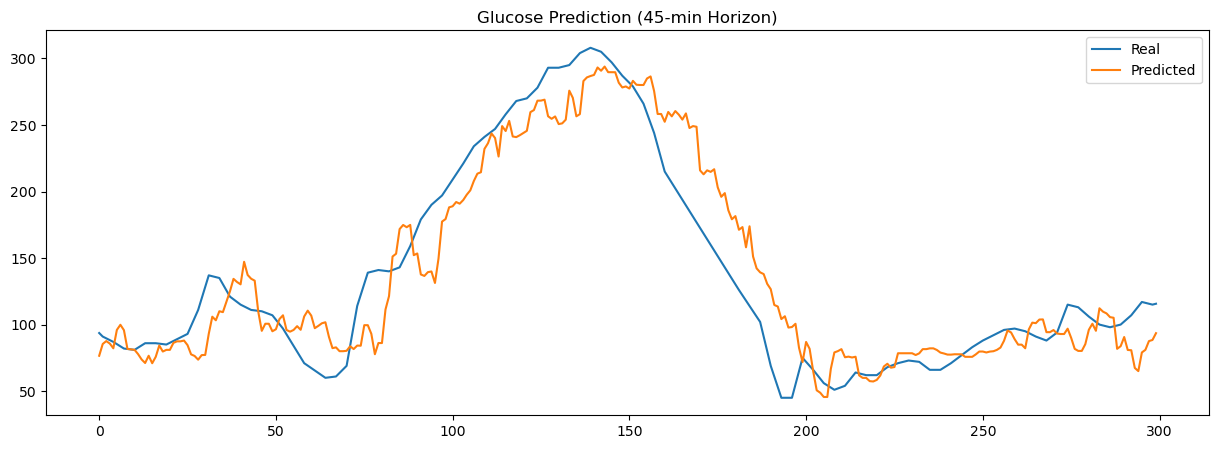

In [401]:
plt.figure(figsize=(15,5))
plt.plot(y_test.values[:300])
plt.plot(pred[:300])
plt.legend(["Real", "Predicted"])
plt.title("Glucose Prediction (45-min Horizon)")
plt.show()

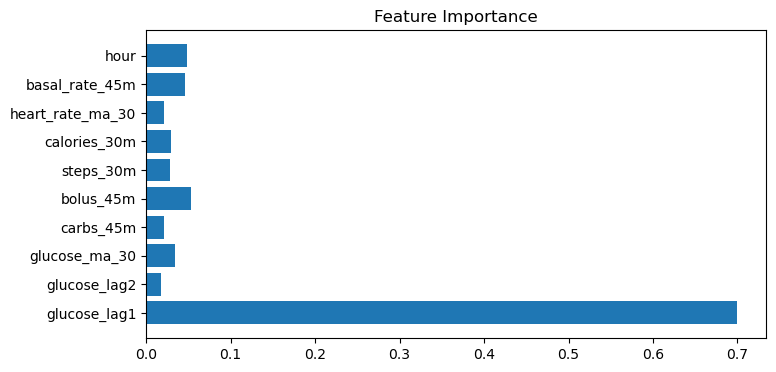

In [402]:
# Visualize feature importance
importance = model.feature_importances_

plt.figure(figsize=(8,4))
plt.barh(features, importance)
plt.title("Feature Importance")
plt.show()

## Model Interpretation

The predictive model captures short-term glucose dynamics.

Key observations:

- The model anticipates postprandial peaks.

- It responds to recent insulin adjustments.

- It captures trend continuation effects.

- It is not the model with the best metrics that could be created, but it is the model that gives all features a minimum level of importance (which is relevant for reinforcement learning).

This model now acts as a surrogate metabolic simulator.

It allows:
- Counterfactual simulation
- Policy testing
- Construction of reinforcement learning environments

In [403]:
# Sensitivity test
# Take a sample from the test set
sample = X_test.iloc[100].copy()

# Normal prediction
normal_pred = model.predict([sample])[0]

# Simulate walking (increase steps_30m)
sample_steps = sample.copy()
sample_steps["steps_30m"] += 1000
pred_steps = model.predict([sample_steps])[0]

# Simulate more carbs (3 servings = 30g)
sample_carbs = sample.copy()
sample_carbs["carbs_45m"] += 3
pred_carbs = model.predict([sample_carbs])[0]

# Simulate more bolus insulin
sample_bolus = sample.copy()
sample_bolus["bolus_45m"] += 1
pred_bolus = model.predict([sample_bolus])[0]

# Simulate more calories burned
sample_calories = sample.copy()
sample_calories["calories_30m"] += 50
pred_calories = model.predict([sample_calories])[0]

# Simulate higher heart rate
sample_hr = sample.copy()
sample_hr["heart_rate_ma_30"] += 5
pred_hr = model.predict([sample_hr])[0]

# Simulate higher basal insulin rate
sample_basal = sample.copy()
sample_basal["basal_rate_45m"] += 0.5
pred_basal = model.predict([sample_basal])[0]

print("Normal prediction:", normal_pred)
print("After walking:", pred_steps)
print("After carbs:", pred_carbs)
print("After bolus:", pred_bolus)
print("After calories burned:", pred_calories)
print("After higher heart rate:", pred_hr)
print("After higher basal insulin rate:", pred_basal)

Normal prediction: 188.93007
After walking: 169.66573
After carbs: 195.79294
After bolus: 187.04274
After calories burned: 186.69154
After higher heart rate: 189.01848
After higher basal insulin rate: 191.25798


## Sensivity test

The sensitivity test is performed to check whether small changes in the predictor variables affect the target variable prediction. The goal is to verify that the model responds in a coherent way to realistic and controlled variations in the input features.

In this case, the model was tested by slightly modifying some patient-related variables, such as increasing steps, carbohydrates intake, insulin bolus, calories burned, heart rate, and basal insulin rate. The new predictions were then compared with the original prediction to observe the impact of these changes.

This test is used to verify that small changes in the input variables produce corresponding changes in the model output, ensuring model sensitivity and consistency.

In [404]:
# Save the model for future use
model_filename = "../models/xgb_glucose_model.pkl"
joblib.dump(model, model_filename)
print(f"Model saved as {model_filename}")

Model saved as ../models/xgb_glucose_model.pkl
